In [3]:
import pandas as pd
import numpy as np

In [4]:
train_df= pd.read_csv("../data/raw/KDDTrain+.txt", header=None)
test_df= pd.read_csv("../data/raw/KDDTest+.txt", header=None)

In [5]:
train_df.head()
test_df.head()

,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
1,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00,normal,21
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00,saint,15
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71,mscan,11


In [6]:
column_names = [
    "duration",
    "protocol_type",
    "service",
    "flag",
    "src_bytes",
    "dst_bytes",
    "land",
    "wrong_fragment",
    "urgent",
    "hot",
    "num_failed_logins",
    "logged_in",
    "num_compromised",
    "root_shell",
    "su_attempted",
    "num_root",
    "num_file_creations",
    "num_shells",
    "num_access_files",
    "num_outbound_cmds",
    "is_host_login",
    "is_guest_login",
    "count",
    "srv_count",
    "serror_rate",
    "srv_serror_rate",
    "rerror_rate",
    "srv_rerror_rate",
    "same_srv_rate",
    "diff_srv_rate",
    "srv_diff_host_rate",
    "dst_host_count",
    "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate",
    "label",
    "difficulty"
]

In [7]:
train_df.columns = column_names
test_df.columns = column_names

In [8]:
train_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [9]:
train_df["label"].value_counts()

label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

In [10]:
train_df['binary_label'] = train_df["label"].apply(lambda x: 0 if x == "normal" else 1)
test_df['binary_label'] = test_df["label"].apply(lambda x: 0 if x == "normal" else 1)

In [11]:
categorical_cols = ["protocol_type", "service", "flag"]

train_df = pd.get_dummies(train_df, columns=categorical_cols)
test_df = pd.get_dummies(test_df, columns=categorical_cols)

train_df, test_df = train_df.align(test_df, join='left', axis=1, fill_value=0)

In [12]:
X_train = train_df.drop(columns=["label", "binary_label", "difficulty"])
X_test = test_df.drop(columns=["label", "binary_label", "difficulty"])

y_test = test_df["binary_label"]

In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler= MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
normal_indices = train_df['binary_label'] == 0

X_training_set = X_train[normal_indices]

In [28]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout

In [29]:
input_dim = X_training_set.shape[1]

input_layer = Input(shape=(input_dim,))
encoded = Dense(64, activation='relu')(input_layer)
encoded = Dropout(0.2)(encoded)
encoded = Dense(32, activation='relu')(encoded)
encoded = Dropout(0.2)(encoded)
encoded = Dense(16, activation='relu')(encoded)
encoded = Dropout(0.2)(encoded)

bottleneck = Dense(8, activation='relu')(encoded)

decoded = Dense(16, activation='relu')(bottleneck)
decoded = Dense(32, activation='relu')(decoded)
decoded = Dense(64, activation='relu')(decoded)

output_layer = Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(inputs=input_layer, outputs=output_layer)

In [ ]:
encoder = Model(inputs=input_layer, outputs=bottleneck)
latent_vectors = encoder.predict(X_test)

705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 759us/step


TypeError: 'tuple' object is not callable

In [30]:
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 122)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         7,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 122)            │         7,930 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,346 (83.38 KB)

 Trainable params: 21,346 (83.38 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
history = autoencoder.fit(X_training_set, X_training_set, epochs=20, batch_size=256, shuffle=True, validation_split=0.2)

Epoch 1/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0450 - val_loss: 0.0126
Epoch 2/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0110 - val_loss: 0.0091
Epoch 3/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0085 - val_loss: 0.0062
Epoch 4/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0066 - val_loss: 0.0053
Epoch 5/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0058 - val_loss: 0.0045
Epoch 6/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0051 - val_loss: 0.0041
Epoch 7/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0048 - val_loss: 0.0038
Epoch 8/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0045 - val_loss: 0.0036
Epoch 9/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0043 - val_loss: 0.0034
Epoch 10/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0041 - val_loss: 0.0033
Epoch 11/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0039 - val_loss: 0.0032
Epoch 12/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

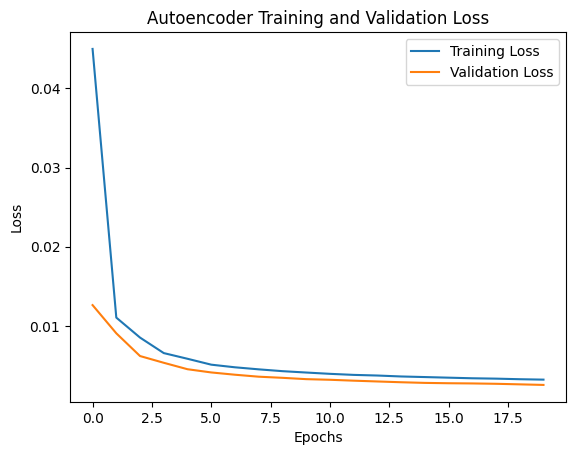

In [32]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Autoencoder Training and Validation Loss')

plt.legend()
plt.show()

In [33]:
reconstructions= autoencoder.predict(X_test)
mse= np.mean(np.square(X_test - reconstructions), axis=1)

705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  


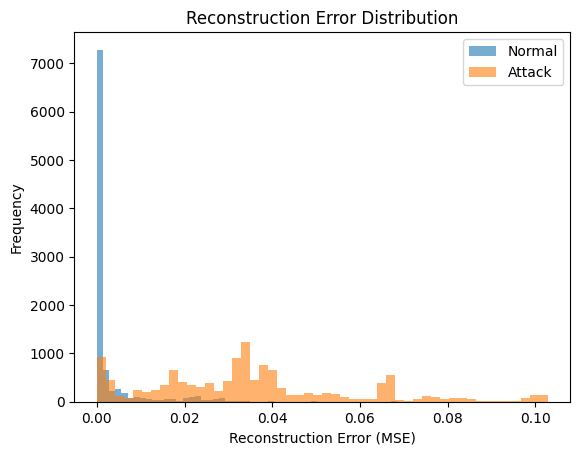

In [34]:
plt.hist(mse[y_test == 0], bins=50, alpha=0.6, label='Normal')
plt.hist(mse[y_test == 1], bins=50, alpha=0.6, label='Attack')

plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Frequency')
plt.title('Reconstruction Error Distribution')

plt.legend()
plt.show()

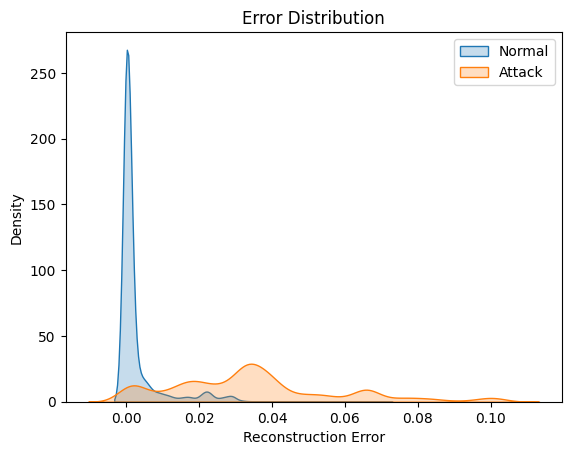

In [35]:
import seaborn as sns

sns.kdeplot(
    mse[y_test == 0],
    label='Normal',
    fill=True
)

sns.kdeplot(
    mse[y_test == 1],
    label='Attack',
    fill=True
)

plt.xlabel("Reconstruction Error")
plt.title("Error Distribution")

plt.legend()
plt.show()

In [36]:
threshold= np.percentile(mse, 55)

In [37]:
y_pred = (mse > threshold).astype(int)

In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, mse))

Accuracy: 0.8279808374733854
Precision: 0.9413504189255791
Recall: 0.7441751733811268
F1 Score: 0.8312298720515275
ROC AUC Score: 0.9465058583140825


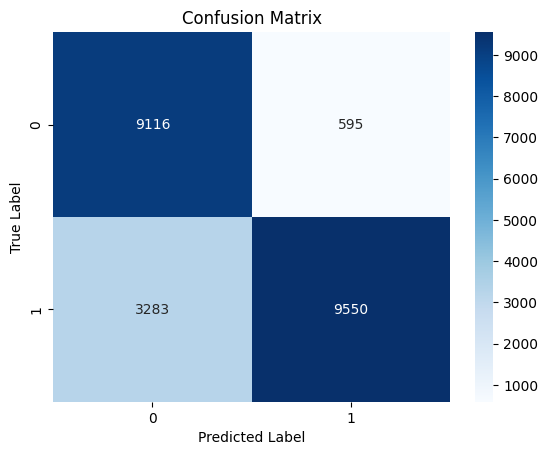

              precision    recall  f1-score   support

           0       0.74      0.94      0.82      9711
           1       0.94      0.74      0.83     12833

    accuracy                           0.83     22544
   macro avg       0.84      0.84      0.83     22544
weighted avg       0.85      0.83      0.83     22544



In [39]:
from sklearn.metrics import classification_report, confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

print(classification_report(y_test, y_pred))

<function matplotlib.pyplot.show(close=None, block=None)>

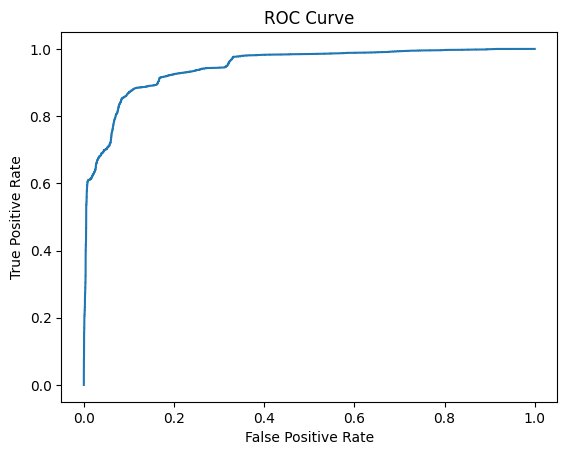

In [40]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, mse)

plt.plot(fpr, tpr, label='Autoencoder ROC Curve')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

plt.show